---
# Task 2: Making Predictions for Specific Users

---
### 0. Import & Config

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import random

from surprise import Dataset, Reader, KNNBasic, SVD

# paths creation, need to adapt to yours
path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2' 

data_path = os.path.join(path, 'datas') 
output = os.path.join(path, 'output') 
preprocessed = os.path.join(path, 'preprocessed') 
figures = os.path.join(path, 'fig') 

MOVIES_PATH = os.path.join(preprocessed, 'movies.csv') 
RATINGS_TRAIN_PATH = os.path.join(preprocessed, 'ratings_train.csv') 
RATINGS_TEST_PATH = os.path.join(data_path, 'ratings_test.csv')

print('Imported and paths created')

Imported and paths created


---
### 1. Loading data

In [13]:
# Load cleaned datasets and target test users
movies = pd.read_csv(MOVIES_PATH) 
ratings_train = pd.read_csv(RATINGS_TRAIN_PATH) 
ratings_test = pd.read_csv(RATINGS_TEST_PATH) 

print('Datas loaded') 
print("------MOVIES--------") 
print(f'movies : {movies.shape}') 
display(movies.head()) 

print("------RATINGS TRAIN--------") 
print(f'ratings_train : {ratings_train.shape}') 
display(ratings_train.head()) 

print("------RATINGS TEST--------") 
print(f'ratings_test : {ratings_test.shape}') 
display(ratings_test.head())

# Retrieve the best model name from Task 1 via JSON for consistency
with open("best_model.json", "r") as f:
    best_model_name = json.load(f)["best_model"]
print(best_model_name)

Datas loaded
------MOVIES--------
movies : (9742, 24)


,movieId,title,genres,year,title_clean,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,Waiting to Exhale,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


------RATINGS TRAIN--------
ratings_train : (97801, 4)


,Unnamed: 0,userId,movieId,rating
0,0,1,1,4.0
1,1,1,3,4.0
2,2,1,6,4.0
3,3,1,47,5.0
4,4,1,50,5.0


------RATINGS TEST--------
ratings_test : (100, 11)


,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


KNN (user-based)


---
### 2. Refit best model on full training set

In [14]:
# Prepare the full training set using Surprise's Reader and Dataset
df_full = ratings_train[['userId', 'movieId', 'rating']]

reader = Reader(rating_scale=(df_full['rating'].min(), df_full['rating'].max()))
data_full = Dataset.load_from_df(df_full, reader)
full_trainset = data_full.build_full_trainset()

# Initialize the optimal model with tuned hyperparameters based on best_model
if best_model_name == 'KNN (user-based)':
    best_model = KNNBasic(
        k=50,
        min_k=3,
        sim_options={'name': 'pearson', 'user_based': True},
        verbose=True
    )
else:
    best_model = SVD(
        n_factors=100,
        n_epochs=30,
        lr_all=0.01,
        reg_all=0.1,
        random_state=42
    )

# Train (fit) the model on the entire dataset
best_model.fit(full_trainset)

print(f'Best model retrained on full dataset: {best_model_name}')

Computing the pearson similarity matrix...
Done computing similarity matrix.
Best model retrained on full dataset: KNN (user-based)


---
### 3. Identifying cold start users

In [15]:
train_users     = set(ratings_train['userId'].unique())
test_users      = set(ratings_test['userId'].unique())
cold_start_users = sorted(test_users - train_users) #cold start = not seen before, hard to recommend
warm_users       = sorted(test_users & train_users) #users with ratings

print(f'Total users to predict for : {len(test_users)}')
print(f'Warm users (in train)       : {len(warm_users)}')
print(f'Cold start users            : {len(cold_start_users)}')
print(f'Cold start IDs              : {cold_start_users}')

Total users to predict for : 100
Warm users (in train)       : 90
Cold start users            : 10
Cold start IDs              : [31, 40, 219, 228, 245, 369, 381, 450, 480, 483]


---
### 4. Cold start Fallback

In [16]:
# If user cold start, we recommend 10 most-popular movies

popularity_fallback = (
    ratings_train.groupby('movieId')
    .agg(n_ratings=('rating', 'count'), mean_rating=('rating', 'mean'))
    .query('n_ratings >= 50')          # minimum credibility threshold
    .sort_values(['n_ratings', 'mean_rating'], ascending=False)
    .head(10)
    .index.tolist()
)

print(f'Cold start fallback ({len(popularity_fallback)} movies):')
cold_recs_df = movies[movies['movieId'].isin(popularity_fallback)][['movieId', 'title_clean']]
display(cold_recs_df)

Cold start fallback (10 movies):


,movieId,title_clean
97,110,Braveheart
224,260,Star Wars: Episode IV - A New Hope
257,296,Pulp Fiction
277,318,"Shawshank Redemption, The"
314,356,Forrest Gump
418,480,Jurassic Park
461,527,Schindler's List
507,589,Terminator 2: Judgment Day
510,593,"Silence of the Lambs, The"
1939,2571,"Matrix, The"


---
### 5. Recommendation function

In [17]:
all_movie_ids = movies['movieId'].unique()

def get_top10_for_user(user_id, model):
    """
    Receives user,model in parameter. Recommend the top 10 
    movieIds sorted for a user.
    """
    # movies already rated by this user
    seen = set(ratings_train[ratings_train['userId'] == user_id]['movieId'])

    #cold start case handling
    if user_id not in warm_users:
        return [mid for mid in popularity_fallback if mid not in seen][:10]

    # predict only on unseen movies
    predictions = [
        (mid, model.predict(user_id, mid).est)
        for mid in all_movie_ids
        if mid not in seen
    ]

    # Sort by predicted rating descending, return top 10
    top10 = sorted(predictions, key=lambda x: x[1], reverse=True)[:10]
    return [mid for mid, _ in top10]



---
### 6. Generate recommendation for all users

In [18]:
all_recommendations = {}
n = len(test_users)

# for all uid apply functions + store results
for i, uid in enumerate(sorted(test_users)):
    all_recommendations[uid] = get_top10_for_user(uid, best_model)
    if (i + 1) % 20 == 0 or (i + 1) == n:
        print(f'  Progress: {i+1}/{n} users done')

print(f'Done — {len(all_recommendations)} users processed.')

  Progress: 20/100 users done
  Progress: 40/100 users done
  Progress: 60/100 users done
  Progress: 80/100 users done
  Progress: 100/100 users done
Done — 100 users processed.


---
### 7. Fill & Saving ratings_test.csv

In [19]:
# Export the filled ratings_test to a CSV file in the output directory

output_df = ratings_test.copy()
rec_cols  = [f'recommendation{i}' for i in range(1, 11)]

for uid, recs in all_recommendations.items():
    idx = output_df[output_df['userId'] == uid].index
    for j, col in enumerate(rec_cols):
        output_df.loc[idx, col] = recs[j]

output_df[rec_cols] = output_df[rec_cols].astype(int)
display(output_df.head(10))

out_path = os.path.join(output, 'ratings_test_filled.csv')
output_df.to_csv(out_path, index=False)
print(f'Saved → {out_path}')

,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,162,1267,2394,1178,215,1223,2648,168252,3201,3019
1,7,6460,174053,38304,7121,31364,115122,2239,6345,1949,2436
2,11,3404,6460,170705,106642,2511,718,5833,1949,98154,6666
3,25,174053,905,62336,177593,3429,27397,55721,3925,2360,1178
4,30,92535,3451,86,3200,93838,905,2202,106642,26471,2732
5,31,356,318,296,593,2571,260,480,110,589,527
6,40,356,318,296,593,2571,260,480,110,589,527
7,56,7121,6184,2925,7044,86504,3152,1446,106642,177593,4437
8,64,6460,174053,26810,171011,2239,3451,5833,7121,115122,177593
9,71,1958,92535,3030,188,3504,89904,2064,171763,5902,4235


Saved → C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2\output\ratings_test_filled.csv


---
### 8. Sanity checks

In [20]:
# Data integrity validation: check for nulls, invalid IDs, and duplicates
# 
missing     = output_df[rec_cols].isnull().sum().sum()
valid_ids   = set(movies['movieId'])
unknown_ids = set(output_df[rec_cols].values.flatten()) - valid_ids
n_dupes     = sum(
    1 for _, row in output_df.iterrows()
    if len(set(row[rec_cols].tolist())) < 10
)

print(f'Missing values           : {missing}   {"OK" if missing == 0 else "ERROR"}')
print(f'Unknown movieIds in recs : {len(unknown_ids)}   {"OK" if len(unknown_ids) == 0 else unknown_ids}')
print(f'Users with duplicate recs: {n_dupes}   {"OK" if n_dupes == 0 else "WARNING"}')

Missing values           : 0   OK
Unknown movieIds in recs : 0   OK
Users with duplicate recs: 0   OK


Plot saved to: C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2\fig\genre_alignment_user_73.png


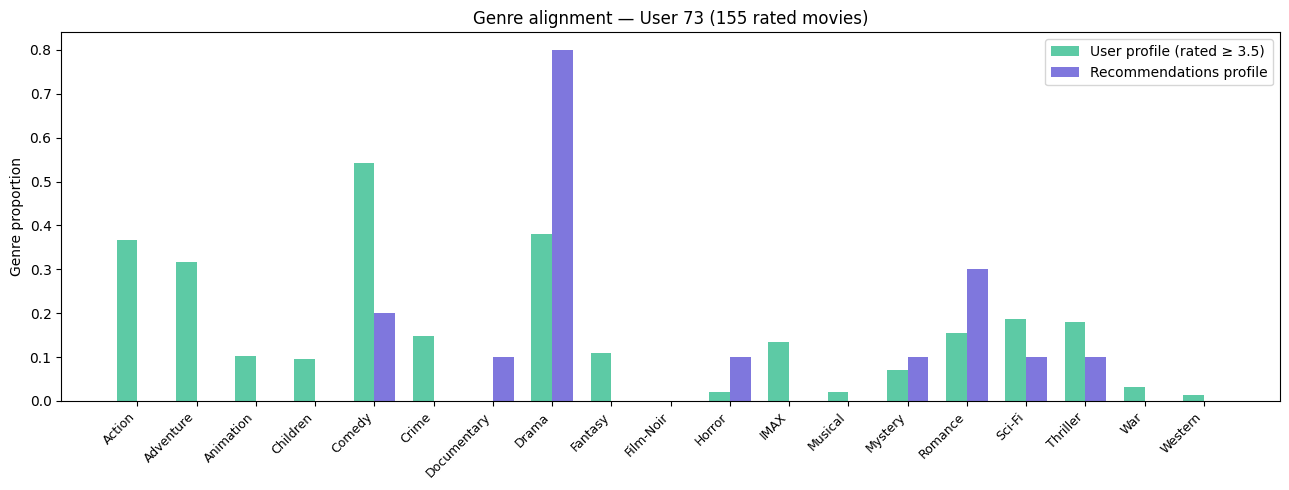

Plot saved to: C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2\fig\genre_alignment_user_232.png


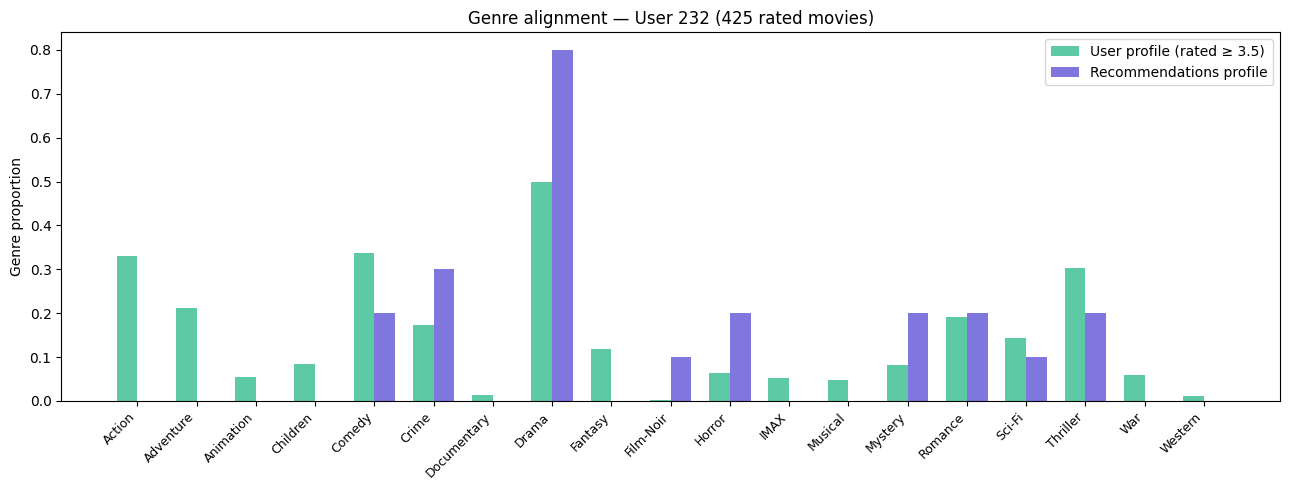

Plot saved to: C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2\fig\genre_alignment_user_312.png


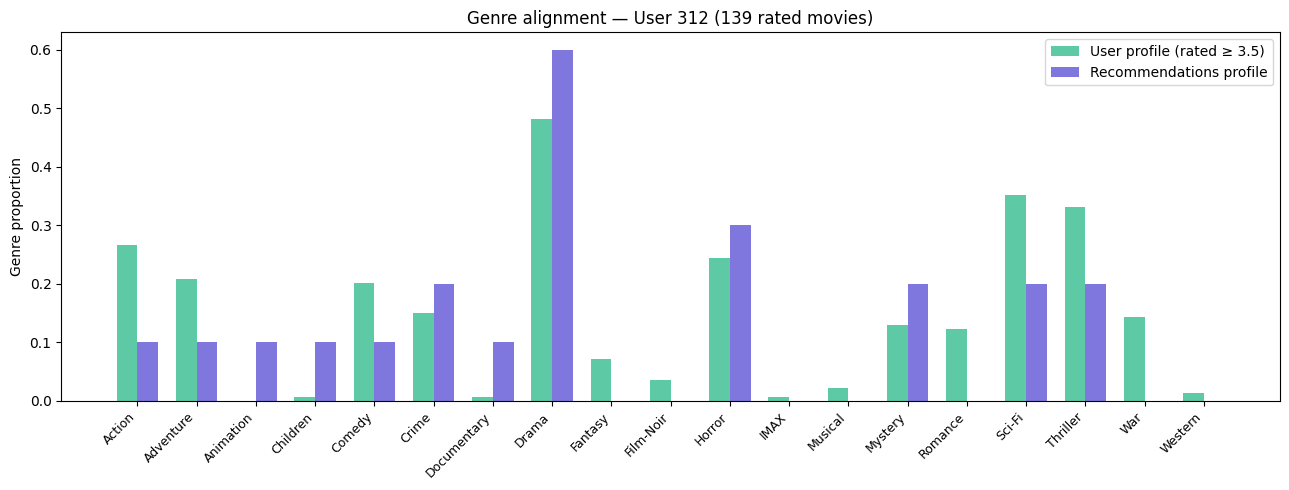

User 369 — cold start, no history.
Plot saved to: C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2\fig\genre_alignment_user_369.png


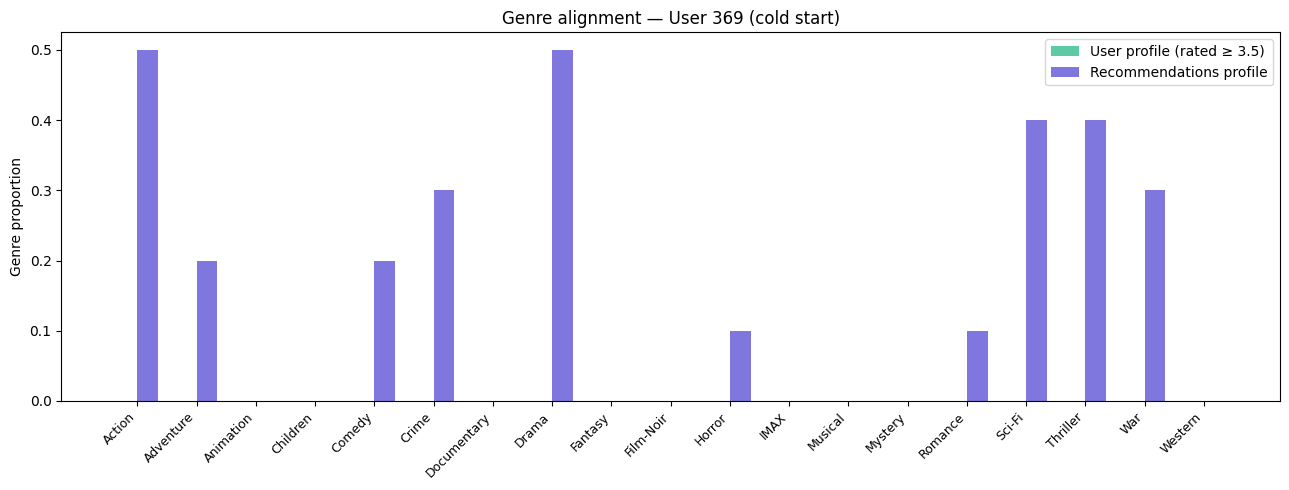

Plot saved to: C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2\fig\genre_alignment_user_452.png


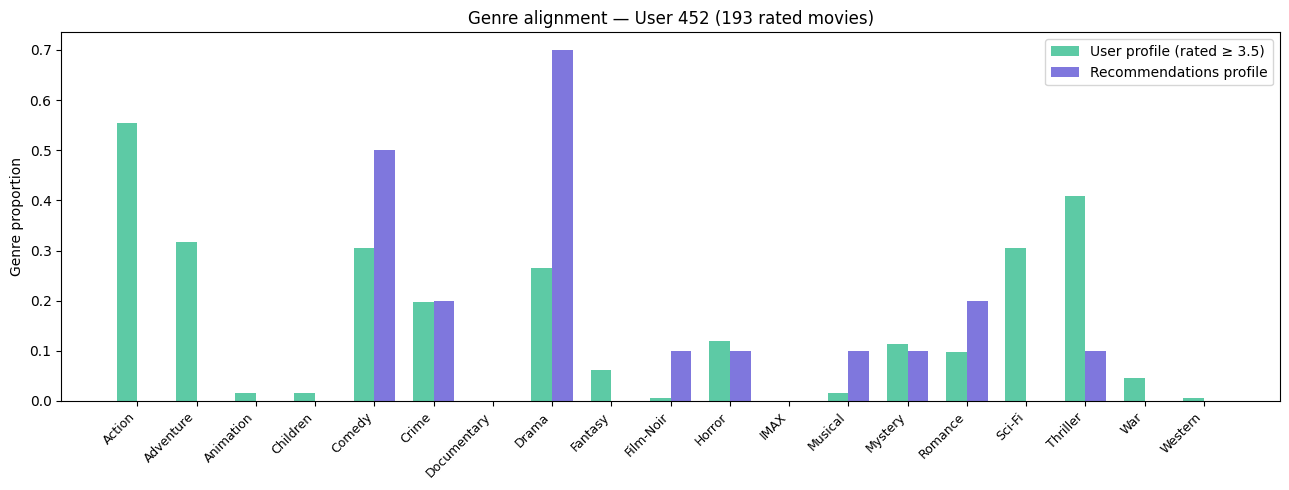

In [21]:
def plot_user_vs_recommendations(user_id, ratings_df, output_df, movies_df):
    '''
    Qualitative analysis, provides plot to compare user genre preference vs Recommendations
    '''
    # Genre columns
    all_genres = sorted(set(
        g for sublist in movies_df['genres'].str.split('|')
        for g in sublist if g != '(no genres listed)'
    ))
    genre_cols         = [f'genre_{g}' for g in all_genres]
    short_genre_names  = all_genres

    # Rebuild one-hot if missing
    for genre, col in zip(all_genres, genre_cols):
        if col not in movies_df.columns:
            movies_df[col] = movies_df['genres'].str.contains(genre, regex=False).astype(int)

    # Extract the 10 recommended movieIds for this user
    rec_cols       = [f'recommendation{i}' for i in range(1, 11)]
    user_row       = output_df[output_df['userId'] == user_id]
    if user_row.empty:
        print(f'User {user_id} not in output — skipping.')
        return
    reco_movie_ids = user_row[rec_cols].values.flatten().astype(int)

    # User profile : mean genre vector of well-rated movies (>= 3.5)
    user_history = ratings_df[(ratings_df['userId'] == user_id) & (ratings_df['rating'] >= 3.5)]
    if user_history.empty:
        print(f'User {user_id} — cold start, no history.')
        user_profile = pd.Series(0, index=genre_cols)
    else:
        user_movies  = movies_df[movies_df['movieId'].isin(user_history['movieId'])]
        user_profile = user_movies[genre_cols].mean()

    # Recommendation profile : mean genre vector of the 10 recommended movies
    reco_movies  = movies_df[movies_df['movieId'].isin(reco_movie_ids)]
    reco_profile = reco_movies[genre_cols].mean()

    # Plot
    x     = np.arange(len(short_genre_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - width/2, user_profile, width, label='User profile (rated ≥ 3.5)', color='#5DCAA5')
    ax.bar(x + width/2, reco_profile, width, label='Recommendations profile',    color='#7F77DD')

    ax.set_ylabel('Genre proportion')
    ax.set_title(
        f'Genre alignment — User {user_id} '
        f'({"cold start" if user_history.empty else f"{len(user_history)} rated movies"})'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(short_genre_names, rotation=45, ha='right', fontsize=9)
    ax.legend()

    filename = f"genre_alignment_user_{user_id}.png"
    save_path = os.path.join(figures, filename) 

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {save_path}")

    plt.tight_layout()
    plt.show()


# Draw random users in [0, 600] — loop until 5 valid ones found
plots_done = 0
while plots_done < 5:
    uid = random.randint(0, 600)
    if uid in output_df['userId'].values:
        plot_user_vs_recommendations(uid, ratings_train, output_df, movies)
        plots_done += 1